**Predição de Aprovação de Pedidos de Cartão de Crédito Utilizando
Aprendizado de Máquina**  

Este projeto tem como objetivo desenvolver um modelo de aprendizado
de máquina capaz de prever se um pedido de cartão de crédito deve ser
aprovado com base em informações pessoais e financeiras dos
solicitantes.

Utilizando técnicas de classificação supervisionadas e uma base
de dados composta por atributos como renda, ocupação, estado civil e histórico
de trabalho, o modelo busca classificar os clientes como "bons" ou "maus"
pagadores, auxiliando instituições financeiras na tomada de decisão quanto à
concessão de crédito.

O projeto aborda as etapas de pré-processamento de
dados, análise exploratória, seleção de atributos, modelagem e avaliação de
desempenho, utilizando diferentes algoritmos.


#**0 — Importanto base de dados**

In [ ]:
import pandas as pd

In [ ]:
df_credit = pd.read_csv("../data/raw/credit_record.csv")
df_credit.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/credit_record.csv'

In [ ]:
df_application = pd.read_csv("../data/raw/application_record.csv")
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


# **1 — Análise Exploratória de Dados - credit_record**

| Coluna           | Significado    | Interpretação                            |
| ---------------- | -------------- | ---------------------------------------- |
| `ID`             | Identification | Identificador do cliente                 |
| `MONTHS_BALANCE` | Months Balance | Mês de referência do registro de crédito |
| `STATUS`         | Credit Status  | Situação do crédito naquele mês          |


In [ ]:
df_credit.shape

(1048575, 3)

In [ ]:
#quantidade de registros e informação de nulos
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [ ]:
df_credit['STATUS'].unique()

array(['X', '0', 'C', '1', '2', '3', '4', '5'], dtype=object)

In [ ]:
#registros duplicados
df_credit.duplicated().sum()

np.int64(0)

In [ ]:
df_credit.duplicated(
    subset=['ID', 'MONTHS_BALANCE']
).sum()

np.int64(0)

In [ ]:
#quantos meses existem de registro
df_credit['MONTHS_BALANCE'].unique()

array([  0,  -1,  -2,  -3,  -4,  -5,  -6,  -7,  -8,  -9, -10, -11, -12,
       -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25,
       -26, -27, -28, -29, -30, -31, -32, -33, -34, -35, -36, -37, -38,
       -39, -40, -41, -42, -43, -44, -45, -46, -47, -48, -49, -50, -51,
       -52, -53, -54, -55, -56, -57, -58, -59, -60])

In [ ]:
#VERIFICANDO SE TODOS OS CLIENTES TÊM 61 MESES DE REGISTRO
meses_por_cliente = df_credit.groupby('ID')['MONTHS_BALANCE'].nunique()
meses_por_cliente.value_counts().sort_index()


,count
MONTHS_BALANCE,
1,399
2,1088
3,1163
4,1339
5,1227
...,...
57,281
58,238
59,242




```
# Observações:
1- não há valores duplicados de registros
2- nem todo cliente ID tem 61 MONTHS_BALANCE de informação. Impossibilitando target com período de cura
```



# **2 — Definição da variável alvo TARGET - credit_record**

0 = menor risco

1 = maior risco


| STATUS | Significado           | Interpretação                                        |
| ------ | --------------------- | ---------------------------------------------------- |
| `C`    | Paid/closed           | Crédito quitado/sem saldo naquele mês                |
| `0`    | 1–29 days past due    | Atraso de 1 a 29 dias                                |
| `1`    | 30–59 days past due   | Atraso de 30 a 59 dias                               |
| `2`    | 60–89 days past due   | Atraso de 60 a 89 dias                               |
| `3`    | 90–119 days past due  | Atraso de 90 a 119 dias                              |
| `4`    | 120–149 days past due | Atraso de 120 a 149 dias                             |
| `5`    | 150+ days past due    | Atraso de 150 dias ou mais                           |
| `X`    | No loan for the month | Sem informação de crédito/sem empréstimo naquele mês |


In [ ]:
#quantidade por tipo de status
df_credit['STATUS'].value_counts(dropna=False)

,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


In [ ]:
#percentual por tipo de status
df_credit['STATUS'].value_counts(normalize=True, dropna=False) * 100

,proportion
STATUS,
C,42.155401
0,36.537205
X,19.953747
1,1.057626
5,0.161457
2,0.082779
3,0.030518
4,0.021267



```
# Observações:
1- forte desbalanceamento da base, grande parte dos clientes está com créditos quitados ou sem informação
```



###   **2.1 Testando a Regra de negócio 1 - RECORRÊNCIA**: considerar maior risco quem teve mais de 50% de ocorrências com 60 dias ou mais de atraso
STATUS >= 2 **nos últimos =~5 anos (61 meses da base)**

In [ ]:
#transformando todos os registros de STATUS em uma variável numérica
df_credit['STATUS_NUM'] = df_credit['STATUS'].replace({
    'C': 0,
    'X': 0
}).astype(int)

In [ ]:
# criando target para status > = 2
target = (
    df_credit
    .groupby('ID')
    .agg(
        TOTAL_MESES=('STATUS_NUM', 'count'),
        MESES_STATUS_2_MAIS=(
            'STATUS_NUM',
            lambda x: (x >= 2).sum()
        )
    )
    .reset_index()
)
target.head()

,ID,TOTAL_MESES,MESES_STATUS_2_MAIS
0,5001711,4,0
1,5001712,19,0
2,5001713,22,0
3,5001714,15,0
4,5001715,60,0


In [ ]:
#calculando percentual em que o cliente ficou com status >=2
target['PERC_STATUS_2_MAIS'] = (
    target['MESES_STATUS_2_MAIS'] /
    target['TOTAL_MESES']
)
target.head()

,ID,TOTAL_MESES,MESES_STATUS_2_MAIS,PERC_STATUS_2_MAIS
0,5001711,4,0,0.0
1,5001712,19,0,0.0
2,5001713,22,0,0.0
3,5001714,15,0,0.0
4,5001715,60,0,0.0


In [ ]:
#criando target para cliente com mais de 50% de registros com status>=2

#0 = menor risco 1 = maior risco



target['TARGET'] = (
    target['PERC_STATUS_2_MAIS'] > 0.50
).astype(int)
target.head()

,ID,TOTAL_MESES,MESES_STATUS_2_MAIS,PERC_STATUS_2_MAIS,TARGET
0,5001711,4,0,0.0,0
1,5001712,19,0,0.0,0
2,5001713,22,0,0.0,0
3,5001714,15,0,0.0,0
4,5001715,60,0,0.0,0


In [ ]:
# identificando TARGET final por quantidade
target['TARGET'].value_counts()

,count
TARGET,
0,45934
1,51


In [ ]:
# identificando TARGET final por percentual
target['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
0,99.889094
1,0.110906


```
# Observações:
1- Regra de negócio 1 - RECORRÊNCIA : desbalanceda, considerando quase todos os clientes como de menor risco 99,8%
```

###   **2.2 Testando a Regra de negócio 2** - considerar de maior risco o cliente que apresentou STATUS >= 2 (atraso de 60 dias ou mais) em pelo menos 1 mês nos últimos =~5 anos (61 meses da base)


**TARGET = 1 cliente que apresentou pelo menos um atraso grave (STATUS >= 2) durante o período de =~ 5 anos.**


In [ ]:
# criando variável com status máximo de cada cliente (ID)
target = (
    df_credit
    .groupby('ID')['STATUS_NUM']
    .max()
    .reset_index()
)

In [ ]:
#criando coluna Target para clientes com status maior ou igual a 60 dias de atraso
target['TARGET'] = (
    target['STATUS_NUM'] >= 2
).astype(int)

In [ ]:
#verificando percentual por target
target['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
0,98.549527
1,1.450473


In [ ]:
clientes_status = (
    df_credit
    .groupby('ID')['STATUS_NUM']
    .max()
)

clientes_status.value_counts().sort_index()

,count
STATUS_NUM,
0,40635
1,4683
2,336
3,88
4,48
5,195


In [ ]:
(clientes_status >= 2).value_counts(normalize=True) * 100

,proportion
STATUS_NUM,
False,98.549527
True,1.450473


```
# Observações:
1- Regra de negócio 2 : desbalanceda, considerando quase todos os clientes como de menor risco 98,5%

*   Item da lista
*   Item da lista


```

In [ ]:
#percentual por tipo de status
df_credit['STATUS'].value_counts(normalize=True, dropna=False) * 100

,proportion
STATUS,
C,42.155401
0,36.537205
X,19.953747
1,1.057626
5,0.161457
2,0.082779
3,0.030518
4,0.021267


```
# Observações:
1- incluir mais clientes do status 0 para balancear a base
```

###   **2.3 Testando a Regra de negócio 3**

- **considerar a reincidência de atraso**. Será de maior risco o cliente que apresentou STATUS = 1 (atraso de 30 dias ou mais) pelo menos 2 vezes durantes =~ 5 anos - 60 meses


- **considerar ocorrência de atraso grave**. Também será de maior risco o cliente que apresentou STATUS >= 2 (atraso de 60 dias ou mais)  pelo vezes 1 vez durantes =~ 5 anos - 60 meses


- **considerar a reincidência de atraso**. Será de maior risco o cliente que apresentou STATUS = 0 (atraso de 1 a 29)  pelo menos 30 vezes durantes =~ 5 anos - 60 meses


TARGET = 1 se:

STATUS = 1 em ≥ 2 meses OU

STATUS ≥ 2 em ≥ 1 mês OU

STATUS = 0 em ≥ 30 meses**

In [ ]:
TARGET3 = (
    df_credit
    .groupby('ID')
    .agg(
        TOTAL_MESES=('STATUS_NUM', 'count'),

        MESES_STATUS_0=(
            'STATUS_NUM',
            lambda x: (x == 0).sum()
        ),

        MESES_STATUS_1=(
            'STATUS_NUM',
            lambda x: (x == 1).sum()
        ),

        MESES_STATUS_2_MAIS=(
            'STATUS_NUM',
            lambda x: (x >= 2).sum()
        )
    )
    .reset_index()
)

In [ ]:
#criando a variável target para a regra de negócio 3
TARGET3['TARGET'] = (
    (TARGET3['MESES_STATUS_1'] >= 2) |
    (TARGET3['MESES_STATUS_2_MAIS'] >= 1) |
    (TARGET3['MESES_STATUS_0'] >= 30)
).astype(int)

In [ ]:
TARGET3['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
0,65.812765
1,34.187235


In [ ]:
#verificando registros duplicados
TARGET3.duplicated(
    subset=['ID', 'TARGET']
).sum()

np.int64(0)

```
# Observações:
1- Regra de negócio 3 a mais balanceada.

In [ ]:
TARGET3.head()

,ID,TOTAL_MESES,MESES_STATUS_0,MESES_STATUS_1,MESES_STATUS_2_MAIS,TARGET
0,5001711,4,4,0,0,0
1,5001712,19,19,0,0,0
2,5001713,22,22,0,0,0
3,5001714,15,15,0,0,0
4,5001715,60,60,0,0,1


#**3 - Definição final da variável-alvo *TARGET***

O cliente será classificado como de **maior risco (TARGET = 1)** quando apresentar:

STATUS = 1: de 30 a 59 dias, pelo menos 2 vezes (recorrência de atraso média) no período de 61 meses OU

STATUS >= 2, 60 dias ou mais, pelo menos uma vez no período de 61 meses (gravidade do atraso) OU

STATUS = 0, de 1 a 29 dias pelo menos 30 vezes (recorrência de atraso moderada) no período de 61 meses




**Caso nenhuma dessas condições seja satisfeita, o cliente será classificado como de menor risco (TARGET = 0)**.

# **4 - Análise Exploratória de Dados - application_record**

In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
df_application.shape

(438557, 18)

In [ ]:
#verificando dados em branco
df_application.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [ ]:
#resumo de campos

for coluna in df_application.select_dtypes(include='object').columns:
    print(f'\n===== {coluna} =====')
    print(df_application[coluna].value_counts(dropna=False))


===== CODE_GENDER =====
CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64

===== FLAG_OWN_CAR =====
FLAG_OWN_CAR
N    275459
Y    163098
Name: count, dtype: int64

===== FLAG_OWN_REALTY =====
FLAG_OWN_REALTY
Y    304074
N    134483
Name: count, dtype: int64

===== NAME_INCOME_TYPE =====
NAME_INCOME_TYPE
Working                 226104
Commercial associate    100757
Pensioner                75493
State servant            36186
Student                     17
Name: count, dtype: int64

===== NAME_EDUCATION_TYPE =====
NAME_EDUCATION_TYPE
Secondary / secondary special    301821
Higher education                 117522
Incomplete higher                 14851
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64

===== NAME_FAMILY_STATUS =====
NAME_FAMILY_STATUS
Married                 299828
Single / not married     55271
Civil marriage           36532
Separated                27251
Widow                    19675
Name: count, dty

In [ ]:
#verificar registros duplicados
df_application.duplicated().sum()

np.int64(0)

# **5 - Pré-processamento - application_record**

In [ ]:
#preenchendo campos em branco de ocupação como "not reported"
df_application['OCCUPATION_TYPE'] = df_application['OCCUPATION_TYPE'].fillna('Not reported')
df_application.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [ ]:
#Tratando coluna DAYS_BIRTH
df_application['DAYS_BIRTH'].describe()

,DAYS_BIRTH
count,438557.000000
mean,-15997.904649
std,4185.030007
min,-25201.000000
25%,-19483.000000
50%,-15630.000000
75%,-12514.000000
max,-7489.000000


```
# Observações:
1- DAYS_BIRTH demonstrou totalidade dos valores negativos
```

In [ ]:
#Criando coluna AGE com base na idade em dias DAYS_BIRTH
df_application['AGE'] = (-df_application['DAYS_BIRTH'] / 365.25).round(1)

In [ ]:
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Not reported,2.0,32.9
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Not reported,2.0,32.9
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58.8
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52.3
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52.3


In [ ]:
#Tratando coluna DAYS_EMPLOYED
df_application['DAYS_EMPLOYED'].describe()

,DAYS_EMPLOYED
count,438557.000000
mean,60563.675328
std,138767.799647
min,-17531.000000
25%,-3103.000000
50%,-1467.000000
75%,-371.000000
max,365243.000000


```
# Observações:
1- DAYS_EMPLOYED demonstrou valores mínimos negativos e máximos positivos. Análise relevante antes do tratamento
```

In [ ]:
# verificando quantidade de valores positivos e negativos
(df_application['DAYS_EMPLOYED'] < 0).value_counts()

,count
DAYS_EMPLOYED,
True,363228
False,75329


In [ ]:
#Investigando quais valores são positivos
df_application_positive = df_application[df_application['DAYS_EMPLOYED'] >= 0]
df_application_positive['DAYS_EMPLOYED'].value_counts().head(20)

,count
DAYS_EMPLOYED,
365243,75329


```
# Observações:
1- Todos os valores positivos são DAYS_EMPLOYED = 365243 ou 365243/365,25≈ 1000 anos
```

In [ ]:
#Investigando a profissão dos valores positivos
df_application[df_application['DAYS_EMPLOYED'] == 365243]['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,75329


In [ ]:
pd.crosstab(
    df_application['NAME_INCOME_TYPE'],
    df_application['DAYS_EMPLOYED'] >= 0,
    normalize='index'
) * 100

DAYS_EMPLOYED,False,True
NAME_INCOME_TYPE,,
Commercial associate,100.000000,0.000000
Pensioner,0.217239,99.782761
State servant,100.000000,0.000000
Student,100.000000,0.000000
Working,100.000000,0.000000


```
# Observações:
1- Os valores positivos correspondem aos pensionistas. Criar variável com registros positivos ajustados como ausentes
```



In [ ]:
#criando variável DAYS_EMPLOYED_CLEAN ajustando os valores positivos como ausentes

df_application['DAYS_EMPLOYED_CLEAN'] = df_application['DAYS_EMPLOYED'].where(
    df_application['DAYS_EMPLOYED'] < 0
)
df_application['DAYS_EMPLOYED_CLEAN']

,DAYS_EMPLOYED_CLEAN
0,-4542.0
1,-4542.0
2,-1134.0
3,-3051.0
4,-3051.0
...,...
438552,NaN
438553,-3007.0
438554,-372.0
438555,NaN


In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
#transformar vaiáveis numéricas de dias para anos e deixar os vazios como 60 para demonstrar pensionistas
df_application['YEARS_EMPLOYED'] = (
    -df_application['DAYS_EMPLOYED_CLEAN'] / 365.25
).fillna(60)
df_application[['YEARS_EMPLOYED', 'DAYS_EMPLOYED']].round(1)

,YEARS_EMPLOYED,DAYS_EMPLOYED
0,12.4,-4542
1,12.4,-4542
2,3.1,-1134
3,8.4,-3051
4,8.4,-3051
...,...,...
438552,60.0,365243
438553,8.2,-3007
438554,1.0,-372
438555,60.0,365243


In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
#análise descritiva de anos de emprego
df_application['YEARS_EMPLOYED'].describe()

,YEARS_EMPLOYED
count,438557.000000
mean,16.253923
std,20.799711
min,0.032854
25%,2.992471
50%,6.880219
75%,16.013689
max,60.000000


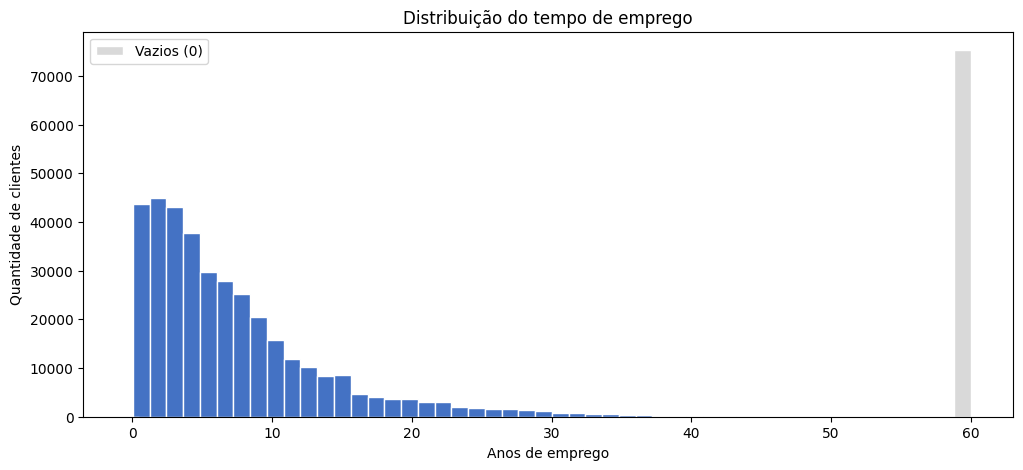

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Valores preenchidos
dados = df_application['YEARS_EMPLOYED'].dropna()

# Quantidade de valores vazios
qtd_vazios = df_application['YEARS_EMPLOYED'].isna().sum()

# Histograma dos valores preenchidos
counts, bins = np.histogram(dados, bins=50)

# Cores das barras
cores = [
    '#D9D9D9' if bin_left >= 50 else '#4472C4'
    for bin_left in bins[:-1]
]

plt.figure(figsize=(12, 5))

# Histograma
plt.bar(
    bins[:-1],
    counts,
    width=np.diff(bins),
    align='edge',
    color=cores,
    edgecolor='white'
)

# Barra dos valores vazios
plt.bar(
    0,
    qtd_vazios,
    width=1,
    color='#D9D9D9',
    edgecolor='white',
    label=f'Vazios ({qtd_vazios:,})'
)

plt.xlabel('Anos de emprego')
plt.ylabel('Quantidade de clientes')
plt.title('Distribuição do tempo de emprego')
plt.legend()

plt.show()

```
# Observações:
1- Concentração em até 10 anos de emprego com os pensionistas separados sem informação
```



# **6 - Pré-processamento - Unir tabelas de dados dos clientes e de informações de TARGET**

In [ ]:
#inner apenas clientes que possuem informações de cadastro + histórico de crédito com TARGET.
df_model = df_application.merge(
    TARGET3[['ID', 'TARGET']],
    on='ID',
    how='inner'
)

In [ ]:
#tamanho da tabela por registros coincidentes
df_model.shape

(36457, 22)

In [ ]:
df_model.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,DAYS_EMPLOYED_CLEAN,YEARS_EMPLOYED,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Not reported,2.0,32.9,-4542.0,12.435318,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Not reported,2.0,32.9,-4542.0,12.435318,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Security staff,2.0,58.8,-1134.0,3.104723,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,52.3,-3051.0,8.353183,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,52.3,-3051.0,8.353183,0


In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

In [ ]:
df_model['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
0,69.25419
1,30.74581


# **7 - Pré-processamento - definindo variáveis do modelo**

In [ ]:
#-excluir a variável ID, DAYS_BIRTH, DAYS_EMPLOYED, DAYS_EMPLOYED_CLEAN e'FLAG_MOBIL (todos os clientes têm celular)  do modelo
df_modela = df_model.drop(columns=['ID', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_EMPLOYED_CLEAN', 'FLAG_MOBIL']).copy()

In [ ]:
df_modela.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CODE_GENDER          36457 non-null  object 
 1   FLAG_OWN_CAR         36457 non-null  object 
 2   FLAG_OWN_REALTY      36457 non-null  object 
 3   CNT_CHILDREN         36457 non-null  int64  
 4   AMT_INCOME_TOTAL     36457 non-null  float64
 5   NAME_INCOME_TYPE     36457 non-null  object 
 6   NAME_EDUCATION_TYPE  36457 non-null  object 
 7   NAME_FAMILY_STATUS   36457 non-null  object 
 8   NAME_HOUSING_TYPE    36457 non-null  object 
 9   FLAG_WORK_PHONE      36457 non-null  int64  
 10  FLAG_PHONE           36457 non-null  int64  
 11  FLAG_EMAIL           36457 non-null  int64  
 12  OCCUPATION_TYPE      36457 non-null  object 
 13  CNT_FAM_MEMBERS      36457 non-null  float64
 14  AGE                  36457 non-null  float64
 15  YEARS_EMPLOYED       36457 non-null 

In [ ]:
# transformando todas as variáveis categóricas para o formato uint8
import pandas as pd

categorical_vars = [
    'CODE_GENDER',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

df_modelb = pd.get_dummies(
    df_modela,
    columns=categorical_vars,
    dtype='uint8'
)

df_modelb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 53 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   FLAG_OWN_CAR                                       36457 non-null  object 
 1   FLAG_OWN_REALTY                                    36457 non-null  object 
 2   CNT_CHILDREN                                       36457 non-null  int64  
 3   AMT_INCOME_TOTAL                                   36457 non-null  float64
 4   FLAG_WORK_PHONE                                    36457 non-null  int64  
 5   FLAG_PHONE                                         36457 non-null  int64  
 6   FLAG_EMAIL                                         36457 non-null  int64  
 7   CNT_FAM_MEMBERS                                    36457 non-null  float64
 8   AGE                                                36457 non-null  float64
 9   YEARS_

In [ ]:
#análise da variável sobre posse de carro
df_modelb['FLAG_OWN_CAR'].value_counts()

,count
FLAG_OWN_CAR,
N,22614
Y,13843


In [ ]:
#transformação binária da coluna FLAG_OWN_CAR (possui carro)
df_modelb['FLAG_OWN_CAR'] = df_modelb['FLAG_OWN_CAR'].map({
    'Y': 1,
    'N': 0
})

In [ ]:
#análise da variável sobre posse de imóvel
df_modelb['FLAG_OWN_REALTY'].value_counts()

,count
FLAG_OWN_REALTY,
Y,24506
N,11951


In [ ]:
#transformação binária da coluna FLAG_OWN_REALTY (possui imóvel)
df_modelb['FLAG_OWN_REALTY'] = df_modelb['FLAG_OWN_REALTY'].map({
    'Y': 1,
    'N': 0
})

In [ ]:
#verificar assimetria da variável Renda Total
df_modelb['AMT_INCOME_TOTAL'].describe().round(1)

,AMT_INCOME_TOTAL
count,36457.0
mean,186685.7
std,101789.2
min,27000.0
25%,121500.0
50%,157500.0
75%,225000.0
max,1575000.0


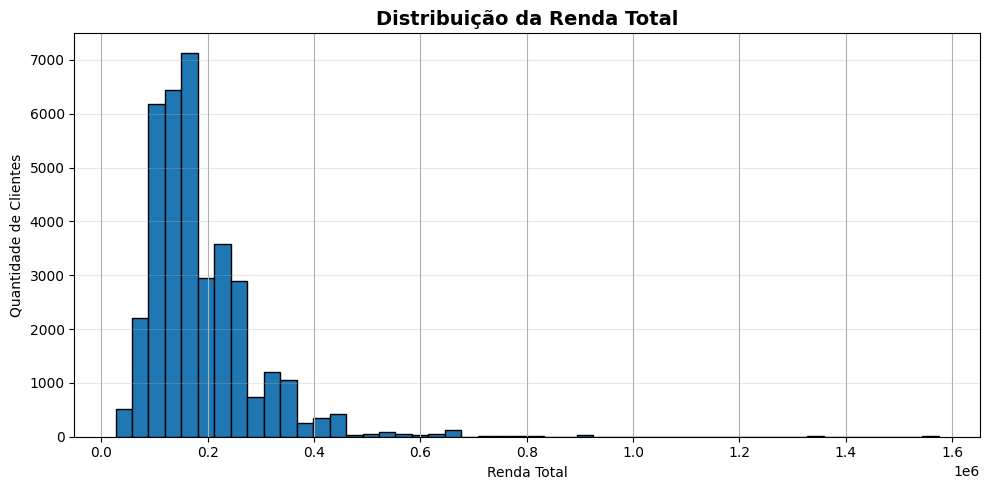

In [ ]:
#identificando graficamente a distribuição de dados da renda
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df_modelb['AMT_INCOME_TOTAL'].hist(
    bins=50,
    edgecolor='black'
)

plt.title('Distribuição da Renda Total', fontsize=14, fontweight='bold')
plt.xlabel('Renda Total')
plt.ylabel('Quantidade de Clientes')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

```
# Observações:
1- Concentração em renda abaixo de 20 mil mas com alguns clientes ganhando até 100 mil
```


In [ ]:
# comprimindo os valores muito grandes para ajudar a tornar a distribuição da renda menos assimétrica
import numpy as np

df_modelb['AMT_INCOME_TOTAL_LOG'] = np.log1p(df_model['AMT_INCOME_TOTAL'])

In [ ]:
df_modelb.head()

,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,...,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Not reported,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,AMT_INCOME_TOTAL_LOG
0,1,1,0,427500.0,1,0,0,2.0,32.9,12.435318,...,0,0,1,0,0,0,0,0,0,12.965712
1,1,1,0,427500.0,1,0,0,2.0,32.9,12.435318,...,0,0,1,0,0,0,0,0,0,12.965712
2,1,1,0,112500.0,0,0,0,2.0,58.8,3.104723,...,0,0,0,0,0,0,0,1,0,11.630717
3,0,1,0,270000.0,0,1,1,1.0,52.3,8.353183,...,0,0,0,0,0,1,0,0,0,12.506181
4,0,1,0,270000.0,0,1,1,1.0,52.3,8.353183,...,0,0,0,0,0,1,0,0,0,12.506181


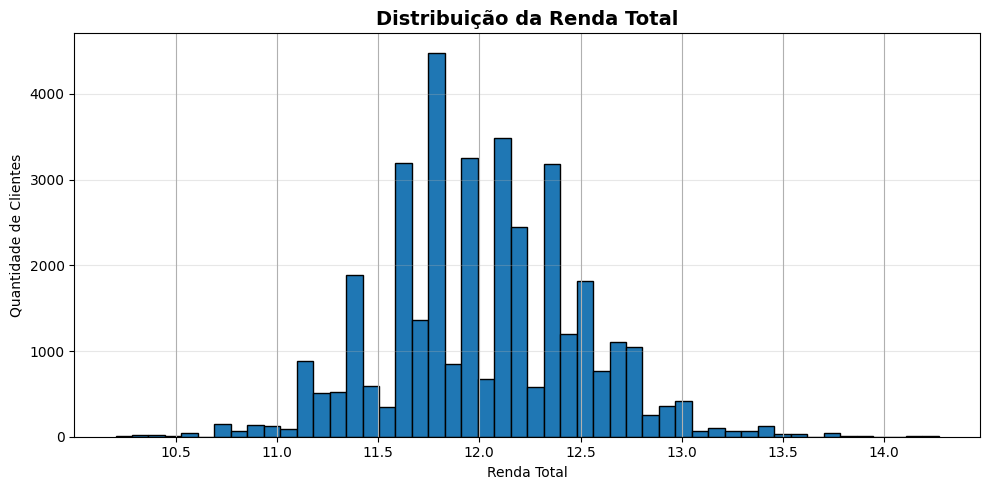

In [ ]:
#identificando graficamente a distribuição de dados da renda na escala logarítmica
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df_modelb['AMT_INCOME_TOTAL_LOG'].hist(
    bins=50,
    edgecolor='black'
)

plt.title('Distribuição da Renda Total', fontsize=14, fontweight='bold')
plt.xlabel('Renda Total')
plt.ylabel('Quantidade de Clientes')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

```
# Observações:
1- renda total balanceada no histograma pela escala logarítmica
```

In [ ]:
#-excluir a variável AMT_INCOME_TOTAL(RENDA) do modelo e deixar apenas o seu correspondente AMT_INCOME_TOTAL_LOG
df_modelc = df_modelb.drop(columns=['AMT_INCOME_TOTAL']).copy()

In [ ]:
df_modelc.head()

,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,TARGET,...,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Not reported,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,AMT_INCOME_TOTAL_LOG
0,1,1,0,1,0,0,2.0,32.9,12.435318,0,...,0,0,1,0,0,0,0,0,0,12.965712
1,1,1,0,1,0,0,2.0,32.9,12.435318,0,...,0,0,1,0,0,0,0,0,0,12.965712
2,1,1,0,0,0,0,2.0,58.8,3.104723,1,...,0,0,0,0,0,0,0,1,0,11.630717
3,0,1,0,0,1,1,1.0,52.3,8.353183,0,...,0,0,0,0,0,1,0,0,0,12.506181
4,0,1,0,0,1,1,1.0,52.3,8.353183,0,...,0,0,0,0,0,1,0,0,0,12.506181


In [ ]:
#verificando a correlação entre a quantidade de membros da família e a quantidade de filhos
df_model[
    ['CNT_CHILDREN',
     'CNT_FAM_MEMBERS']
].corr()

,CNT_CHILDREN,CNT_FAM_MEMBERS
CNT_CHILDREN,1.000000,0.889114
CNT_FAM_MEMBERS,0.889114,1.000000


In [ ]:
#excluindo CNT_FAM_MEMBERS do modelo para deixar apenas CNT_CHILDREN
df_modeld = df_modelc.drop(columns=['CNT_FAM_MEMBERS']).copy()

In [ ]:
df_modeld.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 52 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   FLAG_OWN_CAR                                       36457 non-null  int64  
 1   FLAG_OWN_REALTY                                    36457 non-null  int64  
 2   CNT_CHILDREN                                       36457 non-null  int64  
 3   FLAG_WORK_PHONE                                    36457 non-null  int64  
 4   FLAG_PHONE                                         36457 non-null  int64  
 5   FLAG_EMAIL                                         36457 non-null  int64  
 6   AGE                                                36457 non-null  float64
 7   YEARS_EMPLOYED                                     36457 non-null  float64
 8   TARGET                                             36457 non-null  int64  
 9   CODE_G

# **8 - Modelagem**

In [ ]:
# separar x e y
X = df_modeld.drop(columns=['TARGET'])
y = df_modeld['TARGET']

In [ ]:
X.shape

(36457, 51)

In [ ]:
y.value_counts(normalize=True) * 100

,proportion
TARGET,
0,69.25419
1,30.74581


## **8.1 - Split treino/teste**

In [ ]:
# stratify=y para garantir que a proporção de bons e maus pagadores seja aproximadamente preservada nos dois conjuntos

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# conferindo o balanceamento
y_train.value_counts(normalize=True) * 100

,proportion
TARGET,
0,69.254243
1,30.745757


In [ ]:
# conferindo o balanceamento
y_test.value_counts(normalize=True) * 100

,proportion
TARGET,
0,69.253977
1,30.746023


## **8.2 Modelo 1 - Regressão Logística**

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [ ]:
#escalonamento, SEM fit no conjunto de teste para evitar data leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# como o modelo é desbalanceado pelo TARGET, class_weight='balanced' para atribuir mais peso a classe minoritária
modelo_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
#criar variável de predição
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_prob_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

In [ ]:
#acurácia do modelo
accuracye_lr = round(accuracy_score(y_test, y_pred_lr), 4)
print("Acurácia:", accuracye_lr)

Acurácia: 0.5317


## 8.2.1 Matriz de Confusão do Modelo 1 - Regressão Logística**

In [ ]:

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [ ]:

#Matriz de confusão bons classificados como bons; bons classificados como maus;maus classificados como bons; maus classificados como maus.
confusion_matrix(y_test, y_pred_lr)

array([[2733, 2317],
       [1098, 1144]])

In [ ]:

# linha 1, precisão para maus pagadores
#ROC-AUC: capacidade do modelo de distinguir as duas classes
#PR-AUC: desempenho sobre a classe positiva quando existe desbalanceamento

print(classification_report(y_test, y_pred_lr))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, y_prob_lr)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, y_prob_lr)
)

              precision    recall  f1-score   support

           0       0.71      0.54      0.62      5050
           1       0.33      0.51      0.40      2242

    accuracy                           0.53      7292
   macro avg       0.52      0.53      0.51      7292
weighted avg       0.60      0.53      0.55      7292

ROC-AUC: 0.5475677656971764
PR-AUC: 0.34400164139733547


## **8.3 Modelo 2 - Árvore de Decisão**

In [ ]:
#X31
#Decision Tree não depende da escala dos valores para tomar suas decisões, não precisa rodar o StandardScaler
modelo_tree = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=5
)

modelo_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [ ]:
#criar variável de valores previstos
y_pred_tree = modelo_tree.predict(X_test)

y_prob_tree = modelo_tree.predict_proba(X_test)[:, 1]


In [ ]:
#acurácia do modelo
accuracye_tree = round(accuracy_score(y_test, y_pred_tree), 4)
print("Acurácia:", accuracye_tree)

Acurácia: 0.4904


## 8.3.1 Matriz de Confusão do Modelo 2 - Árvore de Decisão**

In [ ]:

#Matriz de confusão bons classificados como bons; bons classificados como maus;maus classificados como bons; maus classificados como maus.
confusion_matrix(y_test, y_pred_tree)

array([[2027, 3023],
       [ 693, 1549]])

In [ ]:

# linha 1, precisão para maus pagadores
#ROC-AUC: capacidade do modelo de distinguir as duas classes
#PR-AUC:  desempenho sobre a classe positiva quando existe desbalanceamento

print(classification_report(y_test, y_pred_tree))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, y_prob_tree)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, y_prob_tree)
)

              precision    recall  f1-score   support

           0       0.75      0.40      0.52      5050
           1       0.34      0.69      0.45      2242

    accuracy                           0.49      7292
   macro avg       0.54      0.55      0.49      7292
weighted avg       0.62      0.49      0.50      7292

ROC-AUC: 0.5526287084551452
PR-AUC: 0.33413453956891376


## **8.4 Modelo 3 - Random Forest**

In [ ]:

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
#variável de previsões
y_pred_rf = modelo_rf.predict(X_test)

y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

In [ ]:
#acurácia do modelo
accuracye = round(accuracy_score(y_test, y_pred_rf), 4)
print("Acurácia:", accuracye)

Acurácia: 0.6866


## 8.4.1 Matriz de Confusão do Modelo 3 - Random Forest**

In [ ]:

#Matriz de confusão bons classificados como bons; bons classificados como maus;maus classificados como bons; maus classificados como maus.
confusion_matrix(y_test, y_pred_rf)

array([[3731, 1319],
       [ 966, 1276]])

In [ ]:

# linha 1, precisão para maus pagadores
#ROC-AUC: capacidade do modelo de distinguir as duas classes
#PR-AUC:  desempenho sobre a classe positiva quando existe desbalanceamento

print(classification_report(y_test, y_pred_rf))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, y_prob_rf)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, y_prob_rf)
)

              precision    recall  f1-score   support

           0       0.79      0.74      0.77      5050
           1       0.49      0.57      0.53      2242

    accuracy                           0.69      7292
   macro avg       0.64      0.65      0.65      7292
weighted avg       0.70      0.69      0.69      7292

ROC-AUC: 0.7202136529442418
PR-AUC: 0.5099491268349163


## **8.5 Modelo 4 - Gradient Boosting**






In [ ]:
modelo_gb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

modelo_gb.fit(X_train, y_train)

HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200,
                               max_leaf_nodes=15, random_state=42)

In [ ]:
#variável de predição
y_pred_gb = modelo_gb.predict(X_test)

y_prob_gb = modelo_gb.predict_proba(X_test)[:, 1]

In [ ]:
#acurácia do modelo
accuracye = round(accuracy_score(y_test, y_pred_gb), 4)
print("Acurácia:", accuracye)

Acurácia: 0.6931


## 8.5.1 Matriz de Confusão do Modelo 3 - Random Forest**

In [ ]:
#Matriz de confusão bons classificados como bons; bons classificados como maus;maus classificados como bons; maus classificados como maus.
confusion_matrix(y_test, y_pred_gb)

array([[5017,   33],
       [2205,   37]])

In [ ]:
# linha 1, precisão para maus pagadores
#ROC-AUC: capacidade do modelo de distinguir as duas classes
#PR-AUC:  desempenho sobre a classe positiva quando existe desbalanceamento

print(classification_report(y_test, y_pred_gb))

print(
    'ROC-AUC:',
    roc_auc_score(y_test, y_prob_gb)
)

print(
    'PR-AUC:',
    average_precision_score(y_test, y_prob_gb)
)

              precision    recall  f1-score   support

           0       0.69      0.99      0.82      5050
           1       0.53      0.02      0.03      2242

    accuracy                           0.69      7292
   macro avg       0.61      0.50      0.42      7292
weighted avg       0.64      0.69      0.58      7292

ROC-AUC: 0.623003771385167
PR-AUC: 0.41349813385238443


## **9 Comparação de modelos**

**Considerando que as classes de bons e maus pagadores do modelo é desbalanceada. O modelo Random Forest apresentou melhor capacidade de identificação dos maus pagadores, considerando Recall, F1 e PR-AUC.**

| Modelo              | Precision 1 | Recall 1 | F1 1 | ROC-AUC | PR-AUC |
| ------------------- | ----------: | -------: | ---: | ------: | -----: |
| Logistic Regression |    0.33     |   0.51   | 0.40 |  0.5475 | 0.3440 |
| Decision Tree       |    0.34     |   0.69   | 0.45 |  0.5526 | 0.3341 |
| Random Forest       |    0.49     |   0.57   | 0.53 |  0.7202 | 0.5099 |
| Gradient Boosting   |    0.53     |   0.02   | 0.03 |  0.6230 | 0.4134 |




## 9. 1 Threshold (limiar): qual probablidade prevista no Random Forest vais ser o ponto de corte para ativar o Target.

In [ ]:
#Lista de precisão do modelo por probabilidade:
#Precision = % dos clientes considerados de maior risco pelo modelo que realmente são de maior risco
#Recall = % dos clientes de maior risco que realmente foram identificados (Se o objetivo do banco for não deixar passar maus pagadores, aceirar Recall maior mesmo que com menor Precision.)
#F1-score = métrica que busca medir o equilíbrio entre Precision e Recall.
thresholds = np.arange(0.10, 0.75, 0.05)

resultados_threshold = []

for threshold in thresholds:

    y_pred = (y_prob_rf >= threshold).astype(int)

    resultados_threshold.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

df_threshold = pd.DataFrame(resultados_threshold)

df_threshold

,Threshold,Precision,Recall,F1
0,0.10,0.390144,0.893399,0.543113
1,0.15,0.402858,0.867529,0.550212
2,0.20,0.411970,0.841213,0.553079
3,0.25,0.423122,0.806423,0.555027
4,0.30,0.434882,0.764050,0.554279
5,0.35,0.445520,0.718555,0.550017
6,0.40,0.456783,0.662355,0.540688
7,0.45,0.480284,0.603033,0.534704
8,0.50,0.491715,0.569135,0.527600
9,0.55,0.502191,0.511151,0.506631


```
# Observações:
1- Modelo Random Forest com Threshold de 0.10 por priorizar a identificação de clientes de maior risco, proporcionando Recall de 89,3%, ou seja, maior capacidade de identificar os clientes classificados como de maior risco.
```

In [ ]:


importancias = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias = (
    importancias
    .sort_values('Importancia', ascending=False)
    .reset_index(drop=True)
)

importancias.head(10)

,Variavel,Importancia
0,AGE,0.233351
1,AMT_INCOME_TOTAL_LOG,0.163965
2,YEARS_EMPLOYED,0.158684
3,CNT_CHILDREN,0.037595
4,FLAG_OWN_CAR,0.025583
5,FLAG_PHONE,0.024648
6,FLAG_WORK_PHONE,0.021382
7,FLAG_OWN_REALTY,0.020807
8,NAME_EDUCATION_TYPE_Secondary / secondary special,0.016303
9,NAME_INCOME_TYPE_Working,0.016044


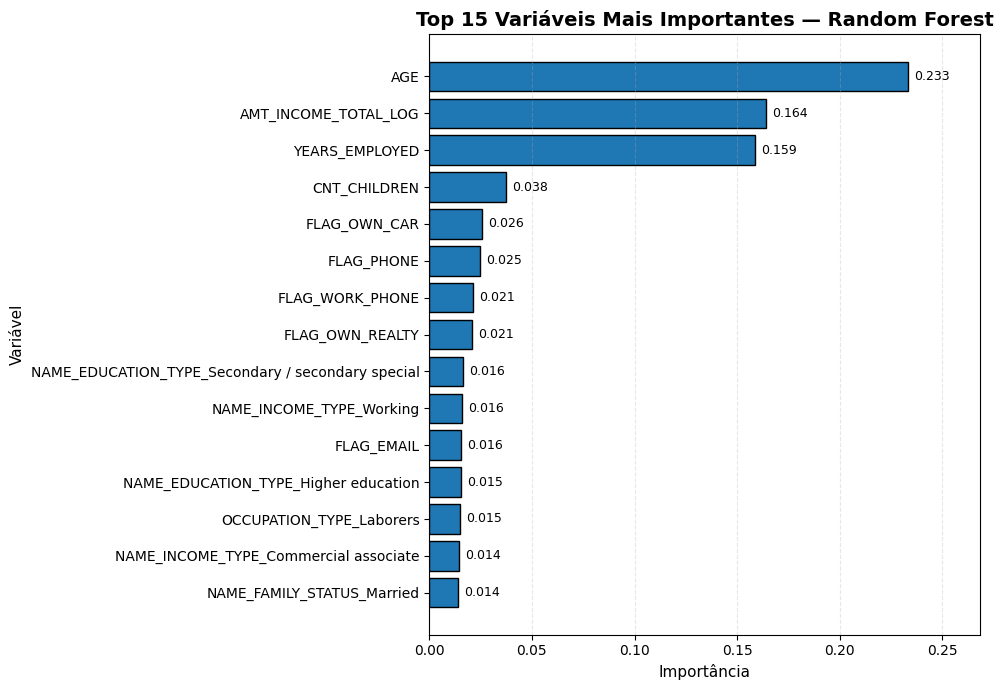

In [ ]:
#importância das variáveis
# Importância das variáveis - Random Forest

import pandas as pd
import matplotlib.pyplot as plt

# Criando DataFrame com as importâncias
importancias = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
})

# Ordenando da maior para a menor importância
importancias = (
    importancias
    .sort_values('Importancia', ascending=False)
    .reset_index(drop=True)
)

# Selecionando as 15 mais importantes
top15 = importancias.head(15).sort_values('Importancia')

# Criando o gráfico
plt.figure(figsize=(10, 7))

barras = plt.barh(
    top15['Variavel'],
    top15['Importancia'],
    edgecolor='black'
)

# Adicionando os valores nas barras
for barra in barras:
    valor = barra.get_width()

    plt.text(
        valor + 0.003,
        barra.get_y() + barra.get_height() / 2,
        f'{valor:.3f}',
        va='center',
        fontsize=9
    )

plt.xlabel('Importância', fontsize=11)
plt.ylabel('Variável', fontsize=11)

plt.title(
    'Top 15 Variáveis Mais Importantes — Random Forest',
    fontsize=14,
    fontweight='bold'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.xlim(0, top15['Importancia'].max() * 1.15)

plt.tight_layout()
plt.show()

```
# Observações:
1- A análise da importância das variáveis do modelo Random Forest mostrou que
 as características com maior contribuição para a capacidade preditiva foram
 AGE (23,3%), AMT_INCOME_TOTAL_LOG (16,4%) e YEARS_EMPLOYED (15,92%). Em
 conjunto, essas três variáveis representam aproximadamente 55% da
 importância total atribuída pelo modelo.


CNT_CHILDREN (3,8%) e FLAG_PHONE (2,6%), com contribuições menores, porém
ainda relevantes para as decisões do modelo.

Os resultados sugerem, assim, que o perfil socioeconômico e a estabilidade
do solicitante são aspectos relevantes para a classificação de risco
realizada pelo modelo.
```
